In [1]:
import torch
import torch.distributions as dist
import neml2
from pyzag import stochastic, nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
import re
import tqdm
import pandas as pd
from neml2.cli.inspect import main as inspect_main
import math
import pyro
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDelta
from pyro.optim import ClippedAdam

In [2]:
torch.manual_seed(0)

torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
device = torch.device(dev)

In [3]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
    """

    def __init__(
        self,
        discrete_equations,
        nchunk=1,
        rtol=1.0e-6,
        atol=1.0e-4,
        initial_rho_m=90.0,
        initial_tau_ss=100.0,
    ):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.cached_solution = None
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m
        self.initial_tau_ss = initial_tau_ss

    def forward(self, loading, time, temperature, cache=False):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder

        Keyword Args:
            cache (bool): if true, cache the solution and use it as a predictor for the next call.
                This heuristic can speed things up during inference where the model is called repeatedly with similar parameter values.
        """
        newton = chunktime.ChunkNewtonRaphsonLineSearch(
            rtol=self.rtol,
            atol=self.atol,
            throw_on_fail=False,
            record_failed=True,
            linesearch_iter=8,
        )
        if cache and self.cached_solution is not None:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.FullTrajectoryPredictor(self.cached_solution),  # type: ignore
                nonlinear_solver=newton,
            )
        else:
            solver = nonlinear.RecursiveNonlinearEquationSolver(
                self.discrete_equations,
                step_generator=nonlinear.StepGenerator(self.nchunk),
                predictor=nonlinear.PreviousStepsPredictor(),  # type: ignore
                nonlinear_solver=newton,
            )

        control = torch.zeros_like(loading)
        control[..., 1:] = 1.0

        # Pack the per-force raw tensors into the single flat forces tensor
        # pyzag consumes. ``assemble_forces`` uses the adapter's own force
        # layout, so the packing is guaranteed to match how the factory later
        # splits the tensor back apart (``_split_by_layout``); base sizes come
        # from the layout, so scalars need no trailing-1 unsqueeze here.
        forces = self.discrete_equations.assemble_forces(
            {
                "fixed_values": loading,
                "t": time,
                "temperature": temperature,
                "control": control,
            }
        )
        state0 = self.discrete_equations.assemble_state(
            {
                "mixed_state": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "log_rho_m": torch.full(
                    forces.shape[1:-1], math.log(self.initial_rho_m), device=forces.device
                ),
                "back_stress": torch.zeros(forces.shape[1:-1] + (6,), device=forces.device),
                "tau_ss": torch.full(forces.shape[1:-1], self.initial_tau_ss, device=forces.device),
            }
        )

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        self.last_failed = newton.failed
        if newton.failed is not None and newton.failed.any():
            raise RuntimeError(
                f"Implicit solve did not succeed for batch entries "
                f"{newton.failed.nonzero().flatten().tolist()}"
            )

        if cache:
            self.cached_solution = result.detach().clone()

        if not torch.isfinite(result).all():
            raise RuntimeError(
                "Non-finite state in the integrated solution: the solve produced NaN/Inf "
                "that pyzag's convergence test did not catch. Reduce nchunk or the step size."
            )

        return result[..., 0:1]

    def density(self, result):
        """Physical mobile dislocation density (um^{-2}) from a solved trajectory."""
        return torch.exp(result[..., 6:7])

In [4]:
nmodel = neml2.load_nonlinear_system("eurofer97.i", "eq_sys")
nmodel.to(device=device)
pmodel = neml2.pyzag.NEML2PyzagModel(
    nmodel,
    include_parameters=[
        "rho_m_rate_k1",
        "rho_m_rate_k2_0",
        "rho_m_rate_Q_d",
        "v_disl_B_k",
        "v_disl_T_0",
        "v_disl_p",
        "v_disl_q",
        "v_disl_H_0",
    ],
)
neml2.compile(pmodel)

model = SolveStrain(pmodel)
_ = inspect_main(["eurofer97.i", "implicit_rate"])

Model: ComposedModel

Inputs (15):
  log_rho_m: type=Scalar
  control: type=SR2
  fixed_values: type=SR2
  mixed_state: type=SR2
  control~1: type=SR2
  fixed_values~1: type=SR2
  mixed_state~1: type=SR2
  temperature: type=Scalar
  t: type=Scalar
  t~1: type=Scalar
  back_stress: type=SR2
  tau_ss: type=Scalar
  back_stress~1: type=SR2
  tau_ss~1: type=Scalar
  log_rho_m~1: type=Scalar

Outputs (4):
  back_stress_residual: type=SR2
  tau_ss_residual: type=Scalar
  log_rho_m_residual: type=Scalar
  stress_residual: type=SR2

Parameters (57):
  rho_m_from_log.scaling: dtype=torch.float64, device=cpu, shape=[]
  rho_m_from_log.rate: dtype=torch.float64, device=cpu, shape=[]
  E.a: dtype=torch.float64, device=cpu, shape=[]
  E.b: dtype=torch.float64, device=cpu, shape=[]
  E.c: dtype=torch.float64, device=cpu, shape=[]
  nu.a: dtype=torch.float64, device=cpu, shape=[]
  nu.b: dtype=torch.float64, device=cpu, shape=[]
  nu.c: dtype=torch.float64, device=cpu, shape=[]
  L.c_lath: dtype=torc

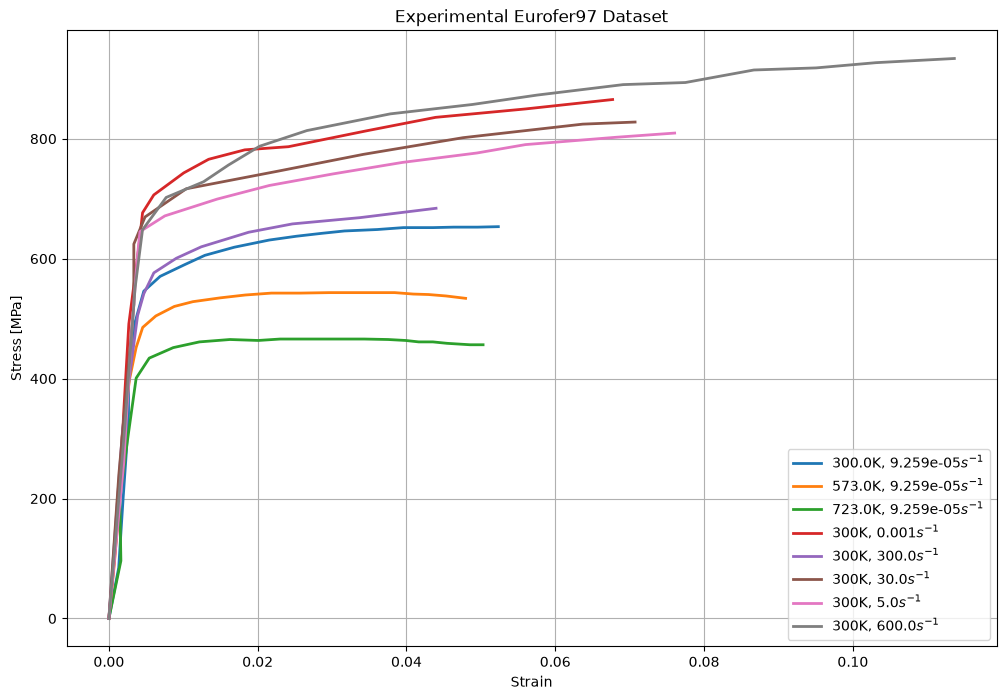

In [5]:
path = "tensile_data/EUROFER97_tensile_dataset"
filenames = [
    f for f in sorted(os.listdir(path)) if f.startswith("Eurofer97") and f.endswith(".csv")
]
exp_conditions = [(f.split("_")[1], f.split("_")[2]) for f in filenames]

RT_K = 300
raw_strain = {}
raw_stress = {}
plt.figure(figsize=(12, 8))
for fname, cond in zip(filenames, exp_conditions):
    _, temp, rate, _ = fname.split("_")
    T = RT_K if temp == "RT" else float(temp.rstrip("k"))
    cond = (T, float(rate))
    df = pd.read_csv(os.path.join(path, fname))
    strain = torch.tensor(df["x"].values, device=device)
    stress = torch.tensor(df["y"].values, device=device)
    raw_strain[cond] = strain[:] - strain[0]
    raw_stress[cond] = stress[:] - stress[0]
    plt.plot(
        raw_strain[cond].cpu().numpy(),
        raw_stress[cond].cpu().numpy(),
        lw=2,
        label=rf"{cond[0]}K, {cond[1]}$s^{{-1}}$",
    )
plt.xlabel("Strain")
plt.ylabel("Stress [MPa]")
plt.title("Experimental Eurofer97 Dataset")
plt.legend()
plt.grid()

In [6]:
batch_conditions = [
    (300, 9.259e-5),
    (573, 9.259e-5),
    (723, 9.259e-5),
    (300, 1.0e-3),
    (300, 5),
    (300, 30),
    (300, 300),
    (300, 600),
]

temps = sorted({round(c[0]) for c in batch_conditions})
rates = torch.tensor([c[1] for c in batch_conditions], device=device)
temp_cmaps = dict(zip(temps, [mpl.cm.Blues, mpl.cm.Greens, mpl.cm.Reds]))
log_rate = np.log10(sorted({c[1] for c in batch_conditions}))


def shade(rate):
    return 0.35 + 0.6 * (np.log10(rate) - log_rate.min()) / (log_rate.max() - log_rate.min())


def cond_color(T, rate):
    return temp_cmaps[round(T)](shade(rate))


nbatch = len(batch_conditions)
ntime = 400
max_strain_list = torch.stack([raw_strain[c][-1] for c in batch_conditions])

time = torch.zeros((ntime, nbatch), device=device)
temperature = torch.zeros((ntime, nbatch), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

for i, (T, rate) in enumerate(batch_conditions):
    loading[:, i, 0] = torch.linspace(0.0, max_strain_list[i], ntime, device=device)
    time[:, i] = torch.linspace(0.0, max_strain_list[i] / rate, ntime, device=device)
    temperature[:, i] = T

print(
    f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}"
)


--- Full Input Tensors ---
time: torch.Size([400, 8])
temperature: torch.Size([400, 8])
loading: torch.Size([400, 8, 6])


Interpolated data shape:
strain: torch.Size([400, 8, 6])
stress: torch.Size([400, 8, 6])


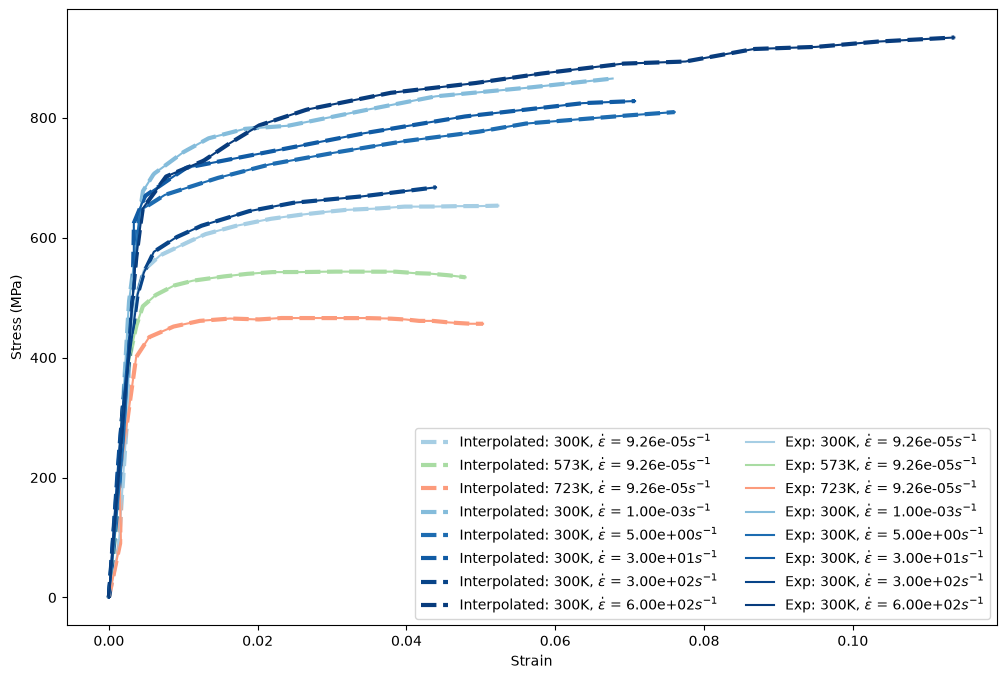

In [7]:
# Convert EXP data into torch tensors
exp_strain_data = torch.zeros_like(loading, device=device)
exp_stress_data = torch.zeros_like(loading, device=device)

for i, (T, rate) in enumerate(batch_conditions):
    target_strains = loading[:, i, 0].cpu().numpy()
    src_strains = raw_strain[(T, rate)].cpu().numpy()
    src_stresses = raw_stress[(T, rate)].cpu().numpy()
    interp_stress = np.interp(target_strains, src_strains, src_stresses)

    exp_strain_data[:, i, 0] = torch.tensor(target_strains, device=device)
    exp_stress_data[:, i, 0] = torch.tensor(interp_stress, device=device)

print(f"Interpolated data shape:")
print(f"strain: {exp_strain_data.shape}")
print(f"stress: {exp_stress_data.shape}")

plt.figure(figsize=(12, 8))
for i, (T, rate) in enumerate(batch_conditions):
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        color=cond_color(T, rate),
        lw=3,
        label=rf"Interpolated: {T}K, $\dot{{\epsilon}}$ = {rate:.2e}$s^{{-1}}$",
    )
for i, (T, rate) in enumerate(batch_conditions):
    plt.plot(
        raw_strain[(T, rate)].cpu().numpy(),
        raw_stress[(T, rate)].cpu().numpy(),
        color=cond_color(T, rate),
        label=rf"Exp: {T}K, $\dot{{\epsilon}}$ = {rate:.2e}$s^{{-1}}$",
    )
plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.legend(ncol=2)

In [8]:
initial_params = {}
print("--- Before Reparametrization ---")
with torch.no_grad():
    for n, p in model.named_parameters():
        initial_params[n] = p.data.detach().clone()
        print(f"{n}: {p.data}, {p.shape}\n")

--- Before Reparametrization ---
discrete_equations.v_disl_B_k: 6.6e-11, torch.Size([])

discrete_equations.v_disl_T_0: 1530.42175, torch.Size([])

discrete_equations.v_disl_p: 0.65, torch.Size([])

discrete_equations.v_disl_q: 1.7, torch.Size([])

discrete_equations.v_disl_H_0: 2.17, torch.Size([])

discrete_equations.rho_m_rate_k1: 78000.0, torch.Size([])

discrete_equations.rho_m_rate_k2_0: 6750.0, torch.Size([])

discrete_equations.rho_m_rate_Q_d: 0.015, torch.Size([])



In [9]:
with torch.no_grad():
    stress = model(loading, time, temperature)
print(stress.shape)

/var/folders/2p/krlq959x6hd3m3plq8gw7sqm0000gn/T/ipykernel_317/29370445.py:52: UserWarning: pyzag lowered torch._functorch.config.donated_buffer's default to False process-wide. AOTAutograd 'donated buffers' (torch>=2.12) are incompatible with pyzag's retain_graph=True adjoint over torch.compile'd models, which otherwise raises 'compiled with non-empty donated buffers'. To keep donated buffers enabled, restore torch._functorch.config._config['donated_buffer'].default = True -- compiled models differentiated through the adjoint will then error.
  solver = nonlinear.RecursiveNonlinearEquationSolver(


torch.Size([400, 8, 1])


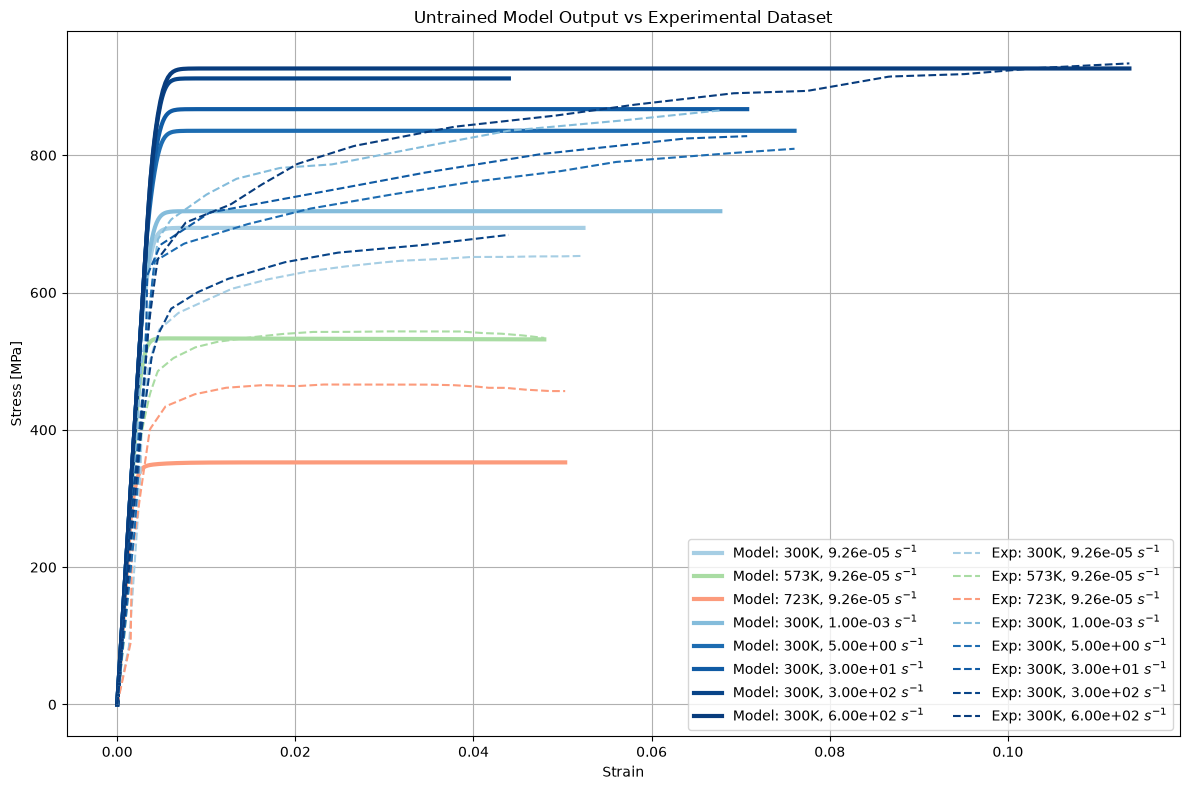

In [10]:
plt.figure(figsize=(12, 8))
for i, (T, rate) in enumerate(batch_conditions):
    batch_label = rf"{T}K, {rate:.2e} $s^{{-1}}$"
    plt.plot(
        loading[:, i, 0].cpu().numpy(),
        stress[:, i, 0].cpu().numpy(),
        color=cond_color(T, rate),
        label=f"Model: {batch_label}",
        lw=3,
    )
for i, (T, rate) in enumerate(batch_conditions):
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        color=cond_color(T, rate),
        label=f"Exp: {T}K, {rate:.2e} $s^{{-1}}$",
    )

plt.legend(loc="lower right", ncol=2)
plt.xlabel("Strain")
plt.ylabel("Stress [MPa]")
plt.title("Untrained Model Output vs Experimental Dataset")
plt.grid()
plt.tight_layout()
plt.show()

In [11]:
class LogRangeRescale(reparametrization.RangeRescale):
    """Map [0, 1] to [lb, ub] in log space, so an Adam step is a relative change."""

    def __init__(
        self,
        lb: torch.Tensor | float,
        ub: torch.Tensor | float,
        clamp: bool = True,
    ) -> None:
        super().__init__(lb, ub, clamp)
        self.lb = math.log(lb)
        self.ub = math.log(ub)
        self.clamp = clamp

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        if self.clamp:
            X = torch.clamp(X, 0, 1)

        return torch.exp(X * (self.ub - self.lb) + self.lb)

    def reverse(self, X: torch.Tensor) -> torch.Tensor:
        Y = (torch.log(X) - self.lb) / (self.ub - self.lb)

        if self.clamp:
            return torch.clamp(Y, 0, 1)

        return Y

In [12]:
Bk_scaler = LogRangeRescale(
    torch.tensor(1.0e-12, device=device), torch.tensor(1.0e-8, device=device)
)  # MPa*s
T_0_scaler = reparametrization.RangeRescale(
    torch.tensor(100.0, device=device), torch.tensor(5000.0, device=device)
)  # K
p_scaler = LogRangeRescale(torch.tensor(0.01, device=device), torch.tensor(1.0, device=device))
q_scaler = LogRangeRescale(torch.tensor(1.0, device=device), torch.tensor(2.0, device=device))
H0_scaler = reparametrization.RangeRescale(
    torch.tensor(0.1, device=device), torch.tensor(10.0, device=device)
)  # eV
k1_scaler = LogRangeRescale(
    torch.tensor(1000.0, device=device), torch.tensor(1.0e7, device=device)
)  # um^-1
k2_0_scaler = LogRangeRescale(
    torch.tensor(0.01, device=device), torch.tensor(100000.0, device=device)
)
Q_d_scaler = LogRangeRescale(
    torch.tensor(0.0001, device=device), torch.tensor(1.0, device=device)
)  # eV

model_reparameterizer = reparametrization.Reparameterizer(
    {
        "discrete_equations.v_disl_B_k": Bk_scaler,
        "discrete_equations.v_disl_T_0": T_0_scaler,
        "discrete_equations.v_disl_p": p_scaler,
        "discrete_equations.v_disl_q": q_scaler,
        "discrete_equations.v_disl_H_0": H0_scaler,
        "discrete_equations.rho_m_rate_k1": k1_scaler,
        "discrete_equations.rho_m_rate_k2_0": k2_0_scaler,
        "discrete_equations.rho_m_rate_Q_d": Q_d_scaler,
    },
    error_not_provided=True,
)
model_reparameterizer(model)
print(f"--- After Reparameterization ---")
initial_params_reparam = {}
for n, p in model.named_parameters():
    initial_params_reparam[n] = p.data.detach().clone()
    print(f"{n}: {p.data}, requires_grad={p.requires_grad}")

--- After Reparameterization ---
discrete_equations.parametrizations.v_disl_B_k.original: 0.4548859838854671, requires_grad=True
discrete_equations.parametrizations.v_disl_T_0.original: 0.291922806122449, requires_grad=True
discrete_equations.parametrizations.v_disl_p.original: 0.9064566783214278, requires_grad=True
discrete_equations.parametrizations.v_disl_q.original: 0.765534746362977, requires_grad=True
discrete_equations.parametrizations.v_disl_H_0.original: 0.20909090909090908, requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k1.original: 0.47302365067262014, requires_grad=True
discrete_equations.parametrizations.rho_m_rate_k2_0.original: 0.8327576818330035, requires_grad=True
discrete_equations.parametrizations.rho_m_rate_Q_d.original: 0.5440228147639202, requires_grad=True


In [13]:
prior_cov = 0.05
prior_noise_scale = 10.0

mapper = stochastic.MapNormal(prior_cov)
hsmodel = stochastic.HierarchicalStatisticalModel(
    model, mapper, torch.tensor(prior_noise_scale, device=device)
)

In [14]:
from pyro import poutine


def predictive_draws(nreps, guide=None):
    """Sample obs one draw at a time, skipping draws who implicit solve fails."""
    draws, failed = [], []
    with torch.no_grad():
        for _ in range(nreps):
            m = hsmodel
            if guide is not None:
                m = poutine.replay(
                    hsmodel, trace=poutine.trace(guide).get_trace(loading, time, temperature)
                )
            tracer = poutine.trace(m)
            try:
                tr = tracer.get_trace(loading, time, temperature)
                draws.append(tr.nodes["obs"]["value"])
            except RuntimeError:
                # The partial trace keeps every parameter sampled before the failure
                failed.append(
                    {
                        n: s["value"].clone()
                        for n, s in tracer.msngr.trace.nodes.items()
                        if s["type"] == "sample" and n.endswith(".original")
                    }
                )
                print(
                    "failed:",
                    [batch_conditions[j] for j in model.last_failed.nonzero().flatten().tolist()],
                )
    print(f"{len(failed)}/{nreps} draws failed the implicit solve")
    return torch.stack(draws), failed

In [15]:
nreps = 50
untrained, failed_prior = predictive_draws(50)
for f in failed_prior:
    for site, v in f.items():
        _, _, pname, _ = site.split(".")
        scaler = model_reparameterizer.map_dict[f"discrete_equations.{pname}"]
        print(f"{pname:18s}", scaler.forward(v).cpu().numpy())
    print()

/opt/anaconda3/envs/neml2/lib/python3.12/site-packages/pyzag/chunktime.py:135: UserWarning: Implicit solve did not succeed.  Results may be inaccurate...
  warnings.warn(


failed: [(300, 9.259e-05)]
failed: [(723, 9.259e-05)]
failed: [(573, 9.259e-05), (723, 9.259e-05)]
failed: [(300, 0.001)]
failed: [(723, 9.259e-05)]
5/50 draws failed the implicit solve
v_disl_B_k         [7.97861006e-11 5.56093123e-11 4.23213598e-11 7.14873693e-11
 8.46997624e-11 8.82085523e-11 4.39191753e-11 1.22503252e-10]
v_disl_T_0         [1565.49514609 1573.26209255 1522.68636991 1550.18129688 1535.40594453
 1584.34655399 1560.5411296  1552.05701416]
v_disl_p           [0.33988841 0.45087073 0.37006237 0.34130192 0.55795353 0.43563601
 0.51751024 0.48225735]
v_disl_q           [1.62632408 1.62849343 1.65330535 1.64365749 1.64051773 1.62393769
 1.62935745 1.62771213]
v_disl_H_0         [2.1546025  2.21872948 2.19886491 2.10792312 2.19203715 2.16710206
 2.2088808  2.14399861]
rho_m_rate_k1      [62738.7009134  73139.57311267 59562.11855829 68732.29140923
 77058.59078911 73996.07394921 62531.29154358 62467.94444942]
rho_m_rate_k2_0    [39096.48391082  1841.74596734  2012.86225395 1

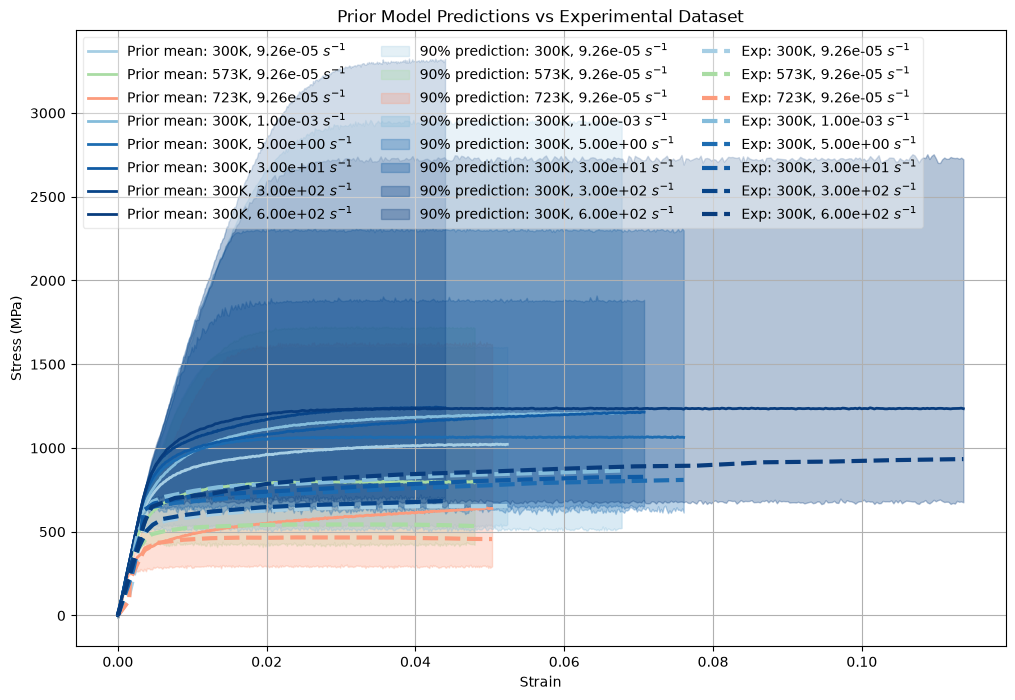

In [16]:
plt.figure(figsize=(12, 8))
plotted_labels = set()
for i, (T, rate) in enumerate(batch_conditions):
    temp_preds = untrained[:, :, i, 0]
    plt.plot(
        loading[:, i, 0].cpu(),
        temp_preds.mean(dim=0).cpu(),
        ls="-",
        color=cond_color(T, rate),
        lw=2,
        label=rf"Prior mean: {T}K, {rate:.2e} $s^{{-1}}$",
    )

for i, (T, rate) in enumerate(batch_conditions):
    temp_preds = untrained[:, :, i, 0]
    lo, hi = torch.quantile(temp_preds, torch.tensor([0.05, 0.95], device=device), dim=0)
    plt.fill_between(
        loading[:, i, 0].cpu(),
        lo.cpu(),
        hi.cpu(),
        color=cond_color(T, rate),
        alpha=0.3,
        label=f"90% prediction: {T}K, {rate:.2e} $s^{{-1}}$",
    )

for i, (T, rate) in enumerate(batch_conditions):
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        lw=3,
        color=cond_color(T, rate),
        label=f"Exp: {T}K, {rate:.2e} $s^{{-1}}$",
    )


plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Prior Model Predictions vs Experimental Dataset")
plt.legend(loc="best", framealpha=0.4, fontsize=10, ncol=3)
plt.grid()
plt.show()

Loss: 5.14e+04: : 100%|██████████|300/300


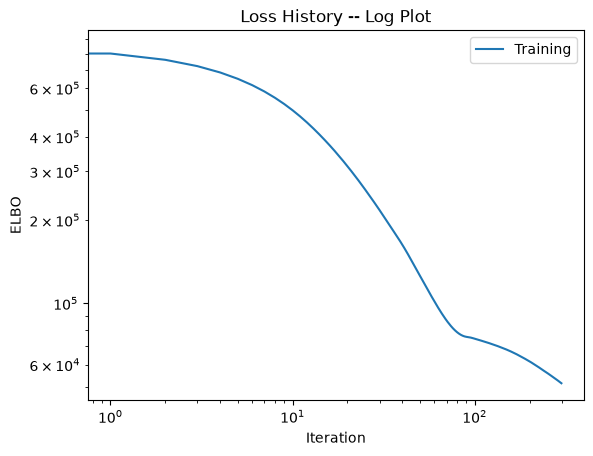

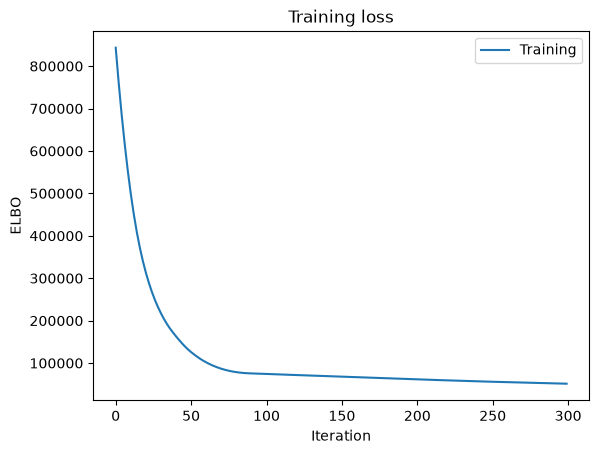

In [17]:
guide = AutoDelta(hsmodel)
lr = 5e-4
niter = 300
num_samples = 1

optimizer = ClippedAdam({"lr": lr})
loss = Trace_ELBO(num_particles=num_samples)
svi = SVI(hsmodel, guide, optimizer, loss=loss)

titer = tqdm.tqdm(
    range(niter),
    bar_format="{desc}: {percentage:3.0f}%|{bar}|{n_fmt}/{total_fmt}{postfix}",
)
titer.set_description("Loss:")
loss_history = []
for i in titer:
    closs = svi.step(loading, time, temperature, results=exp_stress_data[..., 0:1])
    loss_history.append(closs)
    titer.set_description("Loss: %3.2e" % closs)

plt.figure()
plt.loglog(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend(loc="best")
plt.title("Loss History -- Log Plot")

plt.figure()
plt.plot(loss_history, label="Training")
plt.xlabel("Iteration")
plt.ylabel("ELBO")
plt.legend(loc="best")
plt.title("Training loss")
plt.show()

In [18]:
nreps = 50
predict = Predictive(hsmodel, guide=guide, num_samples=nreps)
with torch.no_grad():
    trained = predict(loading, time, temperature)["obs"]

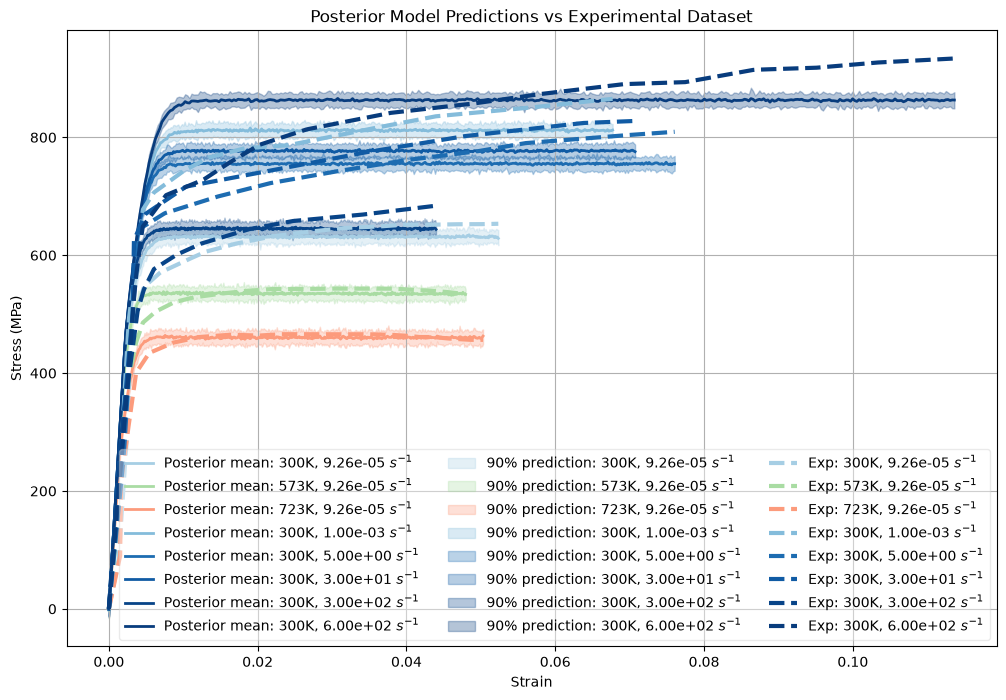

In [19]:
plt.figure(figsize=(12, 8))
plotted_labels = set()
for i, (T, rate) in enumerate(batch_conditions):
    posterior = trained[:, :, i, 0]
    plt.plot(
        loading[:, i, 0].cpu(),
        posterior.mean(dim=0).cpu(),
        ls="-",
        color=cond_color(T, rate),
        lw=2,
        label=rf"Posterior mean: {T}K, {rate:.2e} $s^{{-1}}$",
    )

for i, (T, rate) in enumerate(batch_conditions):
    posterior = trained[:, :, i, 0]
    lo, hi = torch.quantile(posterior, torch.tensor([0.05, 0.95], device=device), dim=0)
    plt.fill_between(
        loading[:, i, 0].cpu(),
        lo.cpu(),
        hi.cpu(),
        color=cond_color(T, rate),
        alpha=0.3,
        label=f"90% prediction: {T}K, {rate:.2e} $s^{{-1}}$",
    )

for i, (T, rate) in enumerate(batch_conditions):
    plt.plot(
        exp_strain_data[:, i, 0].cpu().numpy(),
        exp_stress_data[:, i, 0].cpu().numpy(),
        "--",
        lw=3,
        color=cond_color(T, rate),
        label=f"Exp: {T}K, {rate:.2e} $s^{{-1}}$",
    )


plt.xlabel("Strain")
plt.ylabel("Stress (MPa)")
plt.title("Posterior Model Predictions vs Experimental Dataset")
plt.legend(loc="best", framealpha=0.4, fontsize=10, ncol=3)
plt.grid()
plt.show()

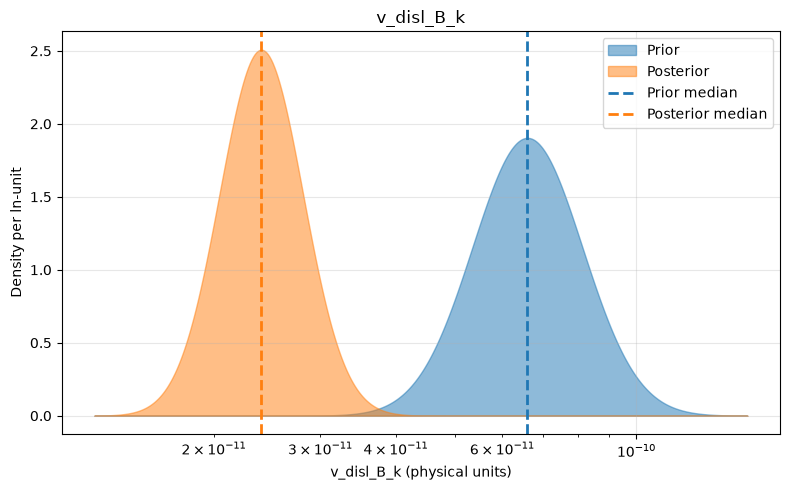

v_disl_B_k: loc = 6.600e-11, scale = 1.233
v_disl_B_k: loc = 2.395e-11, scale = 1.172


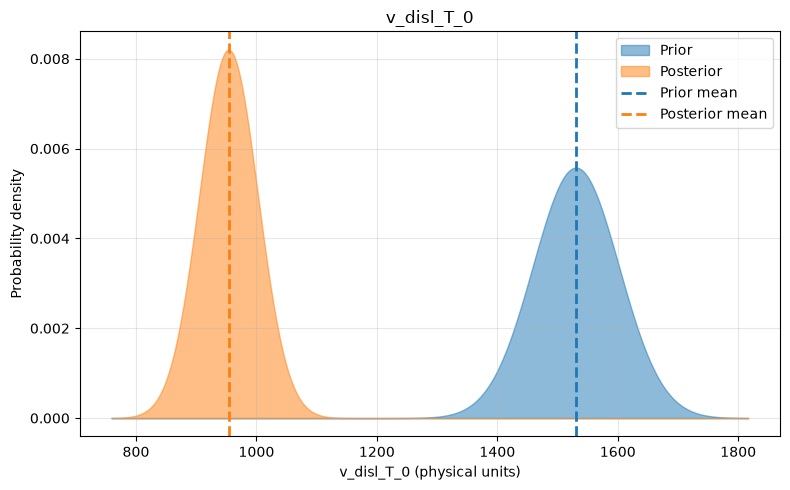

v_disl_T_0: loc = 1530.422, scale = 71.521
v_disl_T_0: loc = 953.800, scale = 48.631


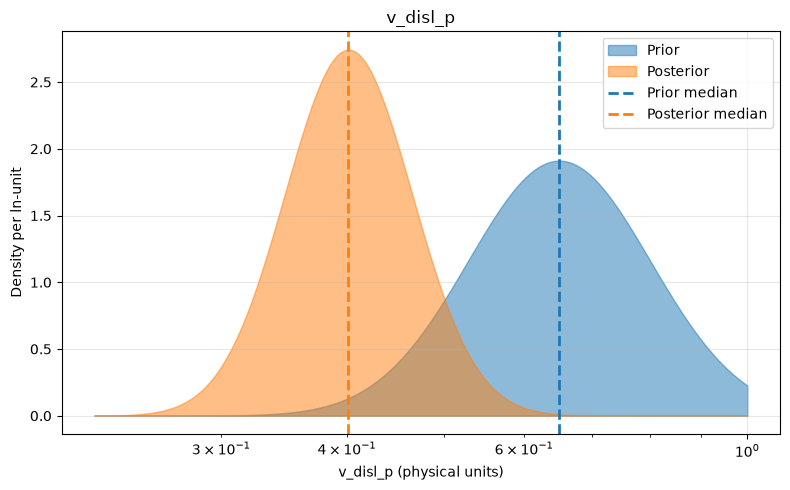

v_disl_p: loc = 0.650, scale = 1.232
v_disl_p: loc = 0.401, scale = 1.157


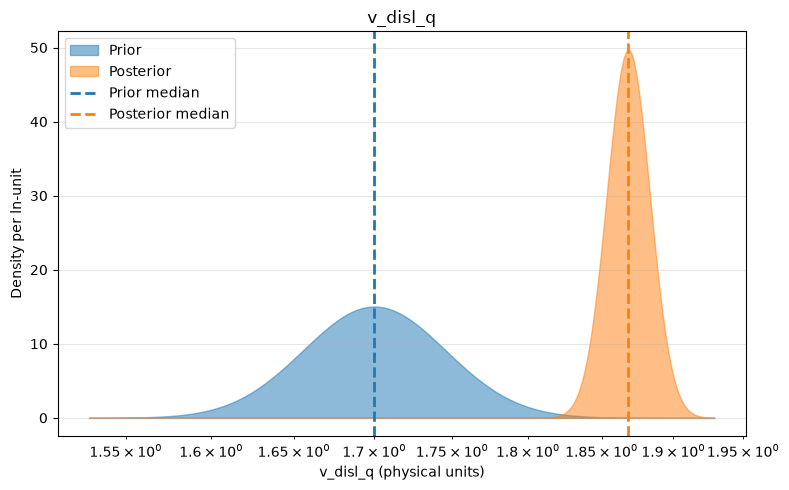

v_disl_q: loc = 1.700, scale = 1.027
v_disl_q: loc = 1.868, scale = 1.008


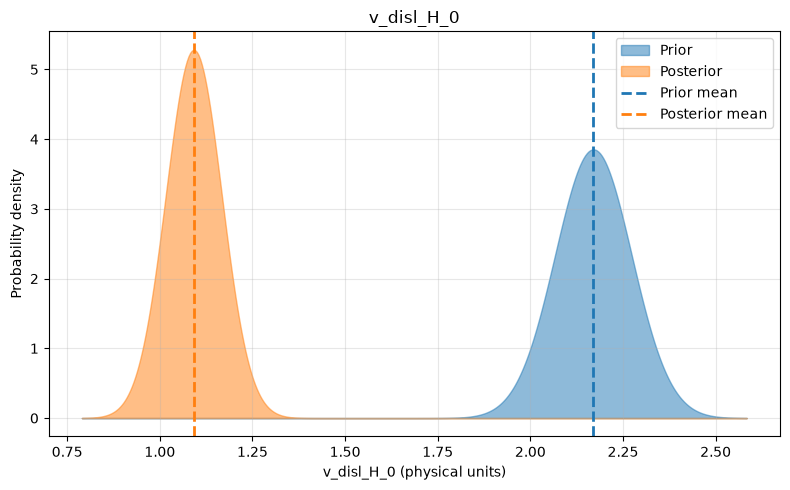

v_disl_H_0: loc = 2.170, scale = 0.103
v_disl_H_0: loc = 1.092, scale = 0.076


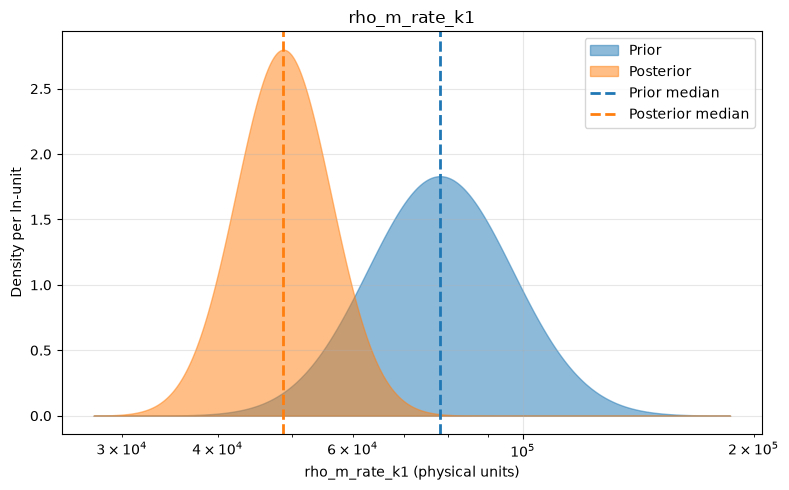

rho_m_rate_k1: loc = 78000.000, scale = 1.243
rho_m_rate_k1: loc = 48729.264, scale = 1.153


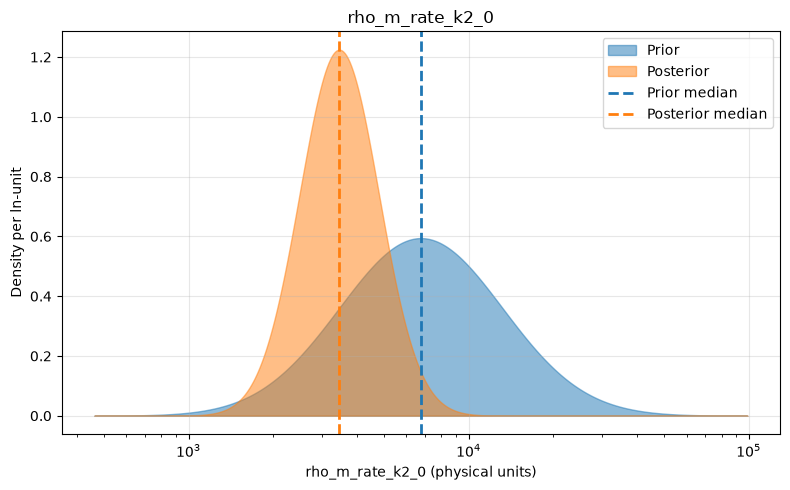

rho_m_rate_k2_0: loc = 6750.000, scale = 1.956
rho_m_rate_k2_0: loc = 3452.027, scale = 1.385


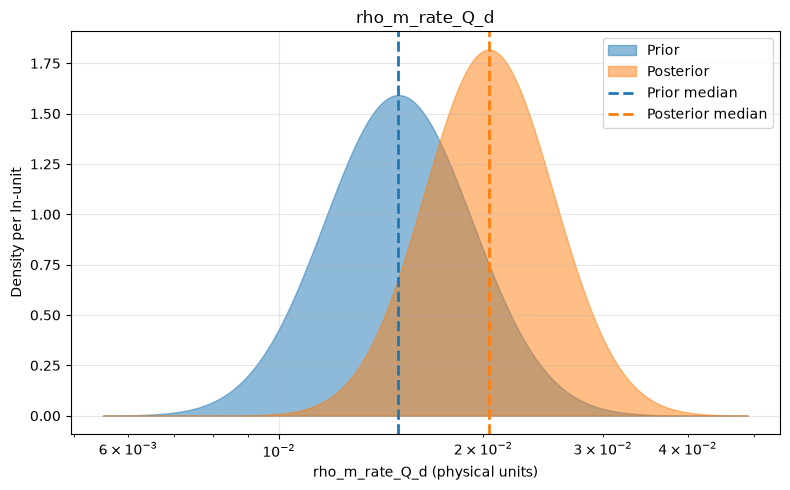

rho_m_rate_Q_d: loc = 0.015, scale = 1.285
rho_m_rate_Q_d: loc = 0.020, scale = 1.245


In [20]:
def scaled_to_physical(scaler, mu, sigma):
    lb, ub = float(scaler.lb), float(scaler.ub)
    return lb + float(mu) * (ub - lb), float(sigma) * abs(ub - lb)


for _, _, n in hsmodel.bot:
    key = ".".join(n.split(".")[i] for i in [0, 2])
    scaler = model_reparameterizer.map_dict[key]
    param_name = key.split(".")[-1]
    is_log = isinstance(scaler, LogRangeRescale)

    # Scaled-space (z) normals
    prior_loc = initial_params_reparam[n]
    prior_scale = prior_cov * prior_loc.abs()
    post_loc = pyro.param(f"AutoDelta.{n}_loc").detach()
    post_scale = pyro.param(f"AutoDelta.{n}_scale").detach()

    # Physical-space normals (in u = theta or ln(theta))
    mu_prior, sigma_prior = scaled_to_physical(scaler, prior_loc, prior_scale)
    mu_post, sigma_post = scaled_to_physical(scaler, post_loc, post_scale)

    # Common grid covering both distribution, limited to the clamp bounds [lb, ub]
    lo = max(min(mu_prior - 4 * sigma_prior, mu_post - 4 * sigma_post), float(scaler.lb))
    hi = min(max(mu_prior + 4 * sigma_prior, mu_post + 4 * sigma_post), float(scaler.ub))
    u = torch.linspace(lo, hi, 400, device=device)

    y_prior = dist.Normal(mu_prior, sigma_prior).log_prob(u).exp()
    y_post = dist.Normal(mu_post, sigma_post).log_prob(u).exp()
    x = u.exp() if is_log else u
    to_x = math.exp if is_log else (lambda v: v)

    plt.figure(figsize=(8, 5))
    plt.fill_between(x.cpu(), y_prior.cpu(), alpha=0.5, color="C0", label="Prior")
    plt.fill_between(x.cpu(), y_post.cpu(), alpha=0.5, color="C1", label="Posterior")
    stat = "median" if is_log else "mean"
    plt.axvline(to_x(mu_prior), color="C0", ls="--", lw=2, label=f"Prior {stat}")
    plt.axvline(to_x(mu_post), color="C1", ls="--", lw=2, label=f"Posterior {stat}")

    if is_log:
        plt.xscale("log")
    plt.xlabel(f"{param_name} (physical units)")
    plt.ylabel("Density per ln-unit" if is_log else "Probability density")
    plt.title(param_name)
    plt.legend(loc="best")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    if param_name == "v_disl_B_k":
        print(rf"{param_name}: loc = {to_x(mu_prior):.3e}, scale = {to_x(sigma_prior):.3f}")
        print(rf"{param_name}: loc = {to_x(mu_post):.3e}, scale = {to_x(sigma_post):.3f}")
    else:
        print(rf"{param_name}: loc = {to_x(mu_prior):.3f}, scale = {to_x(sigma_prior):.3f}")
        print(rf"{param_name}: loc = {to_x(mu_post):.3f}, scale = {to_x(sigma_post):.3f}")